In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df = pd.read_csv('data/bank_marketing_classification_enhanced.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,customer_value,reachability,conversion_likelihood,financial_capacity,balance_category,wealth_age_ratio,log_balance,balance_squared,balance_bin,customer_value_with_balance
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,5,1,6,2,high,36.322034,9.226607,4592449,Q5,8
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,5,1,3,2,low,0.644444,8.993427,841,Q2,5
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,5,1,3,2,low,0.058824,8.990068,4,Q1,5
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,2,1,3,2,medium,31.375000,9.161885,2268036,Q4,5
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,2,1,3,3,low,0.029412,8.989943,1,Q1,2


In [3]:
from sklearn.preprocessing import LabelEncoder

selected_features = ["duration", "duration_squared", "log_duration", "contact_duration_interaction", "contact_quality", "avg_duration_per_contact", "conversion_likelihood", "engaged_call", "prev_success", "campaign_effectiveness", "poutcome", "duration_category", "pdays_clean", "socioeconomic_score"]

X = df[selected_features].copy()

Y = df['y'].values

le = LabelEncoder()
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = le.fit_transform(X[col])

Y = le.fit_transform(Y).astype(np.int64)

X = X.values.astype(np.float32)

unique_counts = np.bincount(Y)
min_class_count = unique_counts.min()
print(f"Original class distribution: {unique_counts}")

X_balanced, Y_balanced = [], []
for cls in np.unique(Y):
    cls_indices = np.where(Y == cls)[0]
    if len(cls_indices) > min_class_count:
        sampled = np.random.choice(cls_indices, size=min_class_count, replace=False)
    else:
        sampled = cls_indices
    X_balanced.append(X[sampled])
    Y_balanced.append(Y[sampled])

X = np.vstack(X_balanced)
Y = np.hstack(Y_balanced)
print(f"Balanced class distribution: {np.bincount(Y)}")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"Train: {np.bincount(Y_train)}, Test: {np.bincount(Y_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1)
x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).unsqueeze(1)
print(x_train_tensor.shape)
print(y_train_tensor.shape)
print(x_test_tensor.shape)
print(y_test_tensor.shape)

Original class distribution: [39922  5289]
Balanced class distribution: [5289 5289]
Train: [4231 4231], Test: [1058 1058]
torch.Size([8462, 14])
torch.Size([8462, 1])
torch.Size([2116, 14])
torch.Size([2116, 1])


In [4]:
from tqdm import tqdm

def train(model, train_loader, test_loader, optimizer, criterion, device, num_epochs):
    model.train()
    history = {"test_loss": [], "train_loss": [], "test_acc": [], "train_acc": []}

    for epoch in range(num_epochs):
        train_loss, train_correct = 0.0, 0
        model.train(True)
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += ((outputs >= 0.0).float() == targets).float().sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = train_correct / len(train_loader.dataset)
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)

        model.eval()
        with torch.no_grad():
            test_loss, test_correct = 0.0, 0
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1} Test", leave=False):
                inputs, targets = batch
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item()
                test_correct += ((outputs >= 0.0).float() == targets).float().sum().item()

        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = test_correct / len(test_loader.dataset)
        history["test_loss"].append(epoch_test_loss)
        history["test_acc"].append(epoch_test_acc)

        tqdm.write(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}"
        )

    return history

In [ ]:
def plot_summary(model_name, train_acc, test_acc, Y_test, Y_pred, Y_prob=None):
    cm = confusion_matrix(Y_test, Y_pred)
    report = classification_report(Y_test, Y_pred, output_dict=True)

    TN, FP, FN, TP = cm.ravel()
    accuracy   = (TP + TN) / (TP + TN + FP + FN)
    precision  = TP / (TP + FP) if (TP + FP) else 0
    recall     = TP / (TP + FN) if (TP + FN) else 0   
    specificity = TN / (TN + FP) if (TN + FP) else 0   
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    has_roc = Y_prob is not None
    n_cols = 3 if has_roc else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))

    im = axes[0].imshow(cm, cmap='Blues')
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha='center', va='center',
                        color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
    plt.colorbar(im, ax=axes[0])

    metrics_names = ['precision', 'recall', 'f1-score']
    classes = [str(c) for c in le.classes_]
    x = np.arange(len(metrics_names))
    width = 0.35
    for idx, cls_name in enumerate(classes):
        vals = [report[str(idx)][m] for m in metrics_names]
        axes[1].bar(x + idx * width, vals, width, label=f'Class {cls_name}')
    axes[1].set_title('Classification Metrics per Class')
    axes[1].set_xticks(x + width / 2)
    axes[1].set_xticklabels(metrics_names)
    axes[1].set_ylim(0, 1.1)
    axes[1].legend()
    axes[1].set_ylabel('Score')

    if has_roc:
        fpr, tpr, _ = roc_curve(Y_test, Y_prob)
        roc_auc = auc(fpr, tpr)
        axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
        axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1.05])
        axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
        axes[2].set_title('ROC Curve')
        axes[2].legend(loc='lower right')
        axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name}  |  Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}')
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*55}")
    print(f"  {model_name} — Detailed Metrics")
    print(f"{'='*55}")
    print(f"  {'Accuracy':<25} {accuracy:.4f}")
    print(f"  {'Precision (PPV)':<25} {precision:.4f}")
    print(f"  {'Sensitivity (Recall/TPR)':<25} {recall:.4f}")
    print(f"  {'Specificity (TNR)':<25} {specificity:.4f}")
    print(f"  {'F1-score':<25} {f1:.4f}")
    if has_roc:
        print(f"  {'AUC':<25} {roc_auc:.4f}")
    print(f"  {'TP':<25} {TP}")
    print(f"  {'TN':<25} {TN}")
    print(f"  {'FP':<25} {FP}")
    print(f"  {'FN':<25} {FN}")
    print(f"{'='*55}")
    print(classification_report(Y_test, Y_pred, target_names=[str(c) for c in le.classes_]))

In [6]:
def plot_loss_history(model_name, history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history['loss'], label='Train Loss', linewidth=2)
    if history['val_loss']:
        axes[0].plot(history['val_loss'], label='Test Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['acc'], label='Train Accuracy', linewidth=2)
    if history['val_acc']:
        axes[1].plot(history['val_acc'], label='Test Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_cluster_summary(model_name, X_2d, cluster_labels, true_labels):
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
    from sklearn.metrics import confusion_matrix as _cm
    import itertools

    n_clusters = len(np.unique(cluster_labels))
    n_classes  = len(np.unique(true_labels))

    from itertools import permutations
    best_labels = cluster_labels.copy()
    best_acc = 0
    for perm in permutations(range(n_clusters)):
        mapped = np.array([perm[l] for l in cluster_labels])
        acc = np.mean(mapped == true_labels)
        if acc > best_acc:
            best_acc = acc
            best_labels = mapped

    sil  = silhouette_score(X_2d, cluster_labels)
    ari  = adjusted_rand_score(true_labels, cluster_labels)
    nmi  = normalized_mutual_info_score(true_labels, cluster_labels)
    purity = best_acc   # cluster purity after best label alignment

    contingency = np.zeros((n_clusters, n_classes), dtype=int)
    for cl, tl in zip(cluster_labels, true_labels):
        contingency[cl, tl] += 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im = axes[0].imshow(contingency, cmap='Blues')
    axes[0].set_title('Contingency Table\n(Cluster vs True Label)')
    axes[0].set_xlabel('True Label')
    axes[0].set_ylabel('Cluster')
    axes[0].set_xticks(range(n_classes))
    axes[0].set_xticklabels([str(c) for c in le.classes_])
    axes[0].set_yticks(range(n_clusters))
    axes[0].set_yticklabels([f'Cluster {k}' for k in range(n_clusters)])
    for i in range(n_clusters):
        for j in range(n_classes):
            axes[0].text(j, i, contingency[i, j], ha='center', va='center',
                         color='white' if contingency[i, j] > contingency.max() / 2 else 'black', fontsize=14)
    plt.colorbar(im, ax=axes[0])

    metric_names = ['Silhouette', 'ARI', 'NMI', 'Purity']
    metric_vals  = [sil, ari, nmi, purity]
    colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
    bars = axes[1].bar(metric_names, metric_vals, color=colors, alpha=0.8)
    axes[1].set_ylim(-0.1, 1.1)
    axes[1].set_title('Clustering Metrics')
    axes[1].set_ylabel('Score')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, metric_vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=11)

    scatter_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for k in range(n_clusters):
        mask = cluster_labels == k
        axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1],
                        color=scatter_colors[k % len(scatter_colors)],
                        alpha=0.4, s=10, label=f'Cluster {k}')
    axes[2].set_title('Cluster Assignments (PCA 2D)')
    axes[2].set_xlabel('PC1')
    axes[2].set_ylabel('PC2')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name}  |  Silhouette: {sil:.4f}  |  ARI: {ari:.4f}  |  NMI: {nmi:.4f}  |  Purity: {purity:.4f}')
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*55}")
    print(f"  {model_name} — Detailed Metrics")
    print(f"{'='*55}")
    print(f"  {'Silhouette Score':<30} {sil:.4f}")
    print(f"  {'Adjusted Rand Index (ARI)':<30} {ari:.4f}")
    print(f"  {'Normalized Mutual Info (NMI)':<30} {nmi:.4f}")
    print(f"  {'Cluster Purity':<30} {purity:.4f}")
    print(f"{'='*55}")
    print(f"\n  Contingency Table (Cluster → True Label):")
    header = "  Cluster  |" + "".join(f"  Class {c}  |" for c in le.classes_)
    print(header)
    print("  " + "-" * (len(header) - 2))
    for k in range(n_clusters):
        row = f"     {k}     |" + "".join(f"    {contingency[k, j]:>4}    |" for j in range(n_classes))
        print(" ", row)
    print(f"{'='*55}")

## Logistic Regression

In [8]:
class LogisticRegression:
    def __init__(self, lr=0.01, num_epochs=1000, fit_intercept=True):
        self.lr = lr
        self.num_epochs = num_epochs
        self.fit_intercept = fit_intercept
        self.weights = None
        self.bias = None
        self.history = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def _binary_ce_loss(self, y, y_pred):
        eps = 1e-7
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}

        for epoch in range(self.num_epochs):
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)

            dw = (X.T @ (y_pred - y)) / n_samples
            db = np.mean(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            loss = self._binary_ce_loss(y, y_pred)
            acc = np.mean((y_pred >= 0.5).astype(int) == y)
            self.history["loss"].append(loss)
            self.history["acc"].append(acc)
            
            if X_val is not None and y_val is not None:
                z_val = X_val @ self.weights + self.bias
                y_val_pred = self.sigmoid(z_val)
                val_loss = self._binary_ce_loss(y_val, y_val_pred)
                val_acc = np.mean((y_val_pred >= 0.5).astype(int) == y_val)
                self.history["val_loss"].append(val_loss)
                self.history["val_acc"].append(val_acc)

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [9]:
log_reg = LogisticRegression(lr=0.01, num_epochs=1000)
log_reg.fit(X_train, Y_train, X_test, Y_test)
train_acc = log_reg.accuracy(X_train, Y_train)
test_acc = log_reg.accuracy(X_test, Y_test)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Y_pred = log_reg.predict(X_test)

Train Accuracy: 0.7785
Test Accuracy: 0.7921


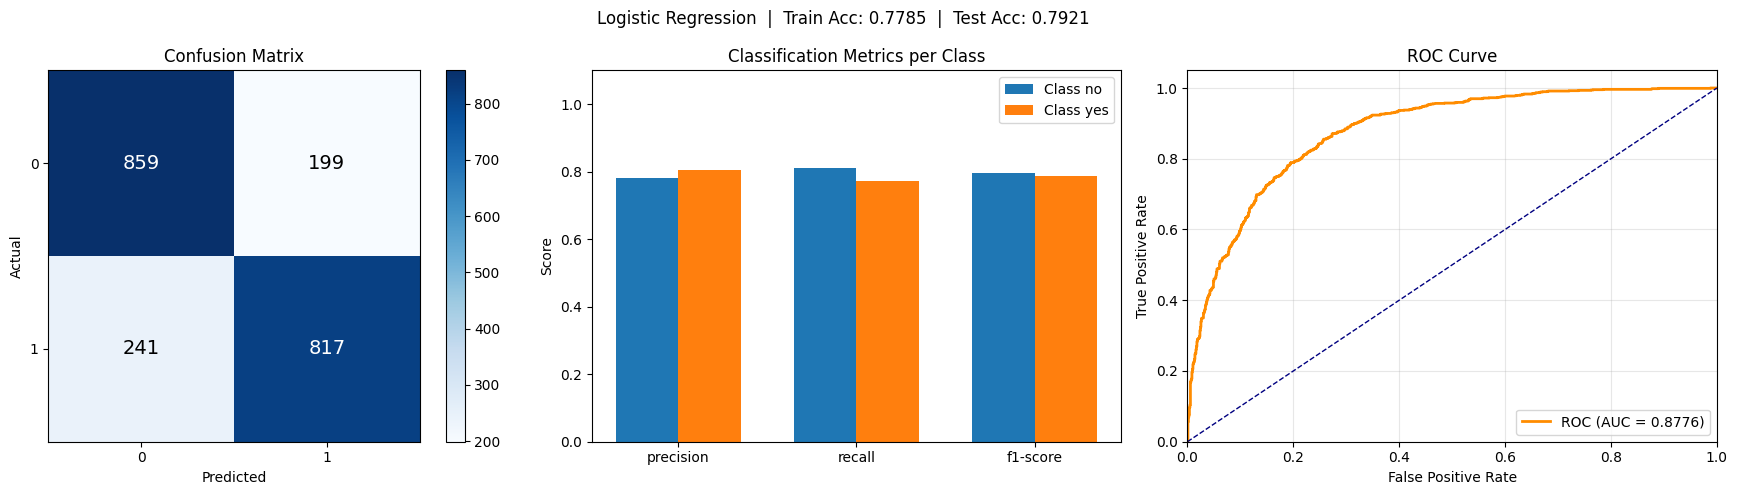


  Logistic Regression — Detailed Metrics
  Accuracy                  0.7921
  Precision (PPV)           0.8041
  Sensitivity (Recall/TPR)  0.7722
  Specificity (TNR)         0.8119
  F1-score                  0.7878
  AUC                       0.8776
  TP                        817
  TN                        859
  FP                        199
  FN                        241
              precision    recall  f1-score   support

          no       0.78      0.81      0.80      1058
         yes       0.80      0.77      0.79      1058

    accuracy                           0.79      2116
   macro avg       0.79      0.79      0.79      2116
weighted avg       0.79      0.79      0.79      2116



In [10]:
Y_prob_lr = log_reg.predict_proba(X_test)
plot_summary("Logistic Regression", train_acc, test_acc, Y_test, Y_pred, Y_prob=Y_prob_lr)

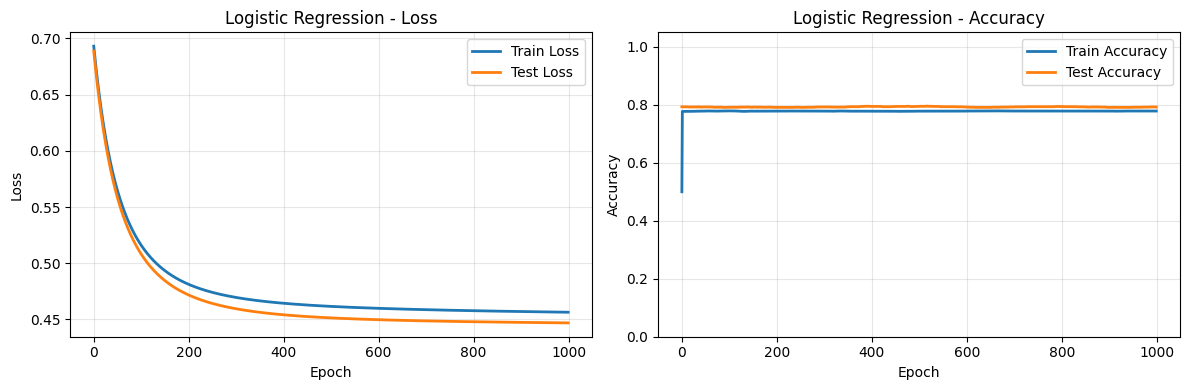

In [11]:
plot_loss_history("Logistic Regression", log_reg.history)

## Decision Tree (Gini, max_depth=20)

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None, class_counts=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.class_counts = class_counts

    def is_leaf(self):
        return self.value is not None

class DecisionTreeGini:
    def __init__(self, max_depth=20, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.history = None

    def _gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feat, best_thresh = None, None
        n_samples, n_features = X.shape

        for feat in range(n_features):
            thresholds = np.unique(X[:, feat])
            for thresh in thresholds:
                left_mask = X[:, feat] <= thresh
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                n_l, n_r = left_mask.sum(), right_mask.sum()
                gini = (n_l / n_samples) * self._gini(y[left_mask]) + \
                       (n_r / n_samples) * self._gini(y[right_mask])

                if gini < best_gini:
                    best_gini = gini
                    best_feat = feat
                    best_thresh = thresh

        return best_feat, best_thresh

    def _build(self, X, y, depth):
        counts = np.bincount(y, minlength=2)
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return Node(value=counts.argmax(), class_counts=counts)

        feat, thresh = self._best_split(X, y)
        if feat is None:
            return Node(value=counts.argmax(), class_counts=counts)

        left_mask = X[:, feat] <= thresh
        left = self._build(X[left_mask], y[left_mask], depth + 1)
        right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return Node(feature=feat, threshold=thresh, left=left, right=right)

    def fit(self, X, y, X_val=None, y_val=None):
        self.root = self._build(X, y.astype(int), depth=0)
        
        self.history = {"acc": [], "val_acc": [], "loss": [], "val_loss": []}
        train_acc = self.accuracy(X, y)
        self.history["acc"].append(train_acc)
        
        if X_val is not None and y_val is not None:
            val_acc = self.accuracy(X_val, y_val)
            self.history["val_acc"].append(val_acc)

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def _predict_proba_one(self, x, node):
        if node.is_leaf():
            total = node.class_counts.sum()
            return node.class_counts[1] / total if total > 0 else 0.0
        if x[node.feature] <= node.threshold:
            return self._predict_proba_one(x, node.left)
        return self._predict_proba_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def predict_proba(self, X):
        return np.array([self._predict_proba_one(x, self.root) for x in X])

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [13]:
dt = DecisionTreeGini(max_depth=20)
dt.fit(X_train, Y_train, X_test, Y_test)

dt_train_acc = dt.accuracy(X_train, Y_train)
dt_test_acc  = dt.accuracy(X_test, Y_test)

dt_pred = dt.predict(X_test)

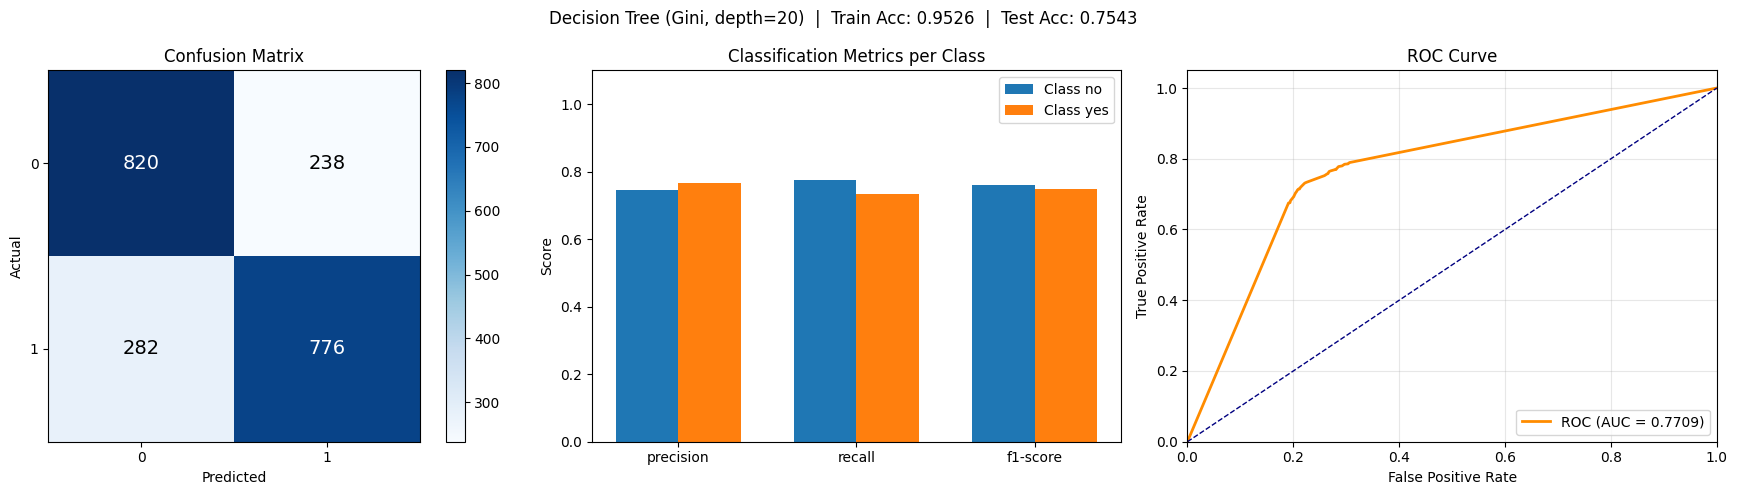


  Decision Tree (Gini, depth=20) — Detailed Metrics
  Accuracy                  0.7543
  Precision (PPV)           0.7653
  Sensitivity (Recall/TPR)  0.7335
  Specificity (TNR)         0.7750
  F1-score                  0.7490
  AUC                       0.7709
  TP                        776
  TN                        820
  FP                        238
  FN                        282
              precision    recall  f1-score   support

          no       0.74      0.78      0.76      1058
         yes       0.77      0.73      0.75      1058

    accuracy                           0.75      2116
   macro avg       0.75      0.75      0.75      2116
weighted avg       0.75      0.75      0.75      2116



In [14]:
dt_prob = dt.predict_proba(X_test)
plot_summary("Decision Tree (Gini, depth=20)", dt_train_acc, dt_test_acc, Y_test, dt_pred, Y_prob=dt_prob)

## Ensemble learning: Random Forest

In [15]:
class RandomForest:
    def __init__(self, n_trees=100, max_depth=20, min_samples_split=2):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.history = None

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples = X.shape[0]
        self.trees = []
        
        for i in tqdm(range(self.n_trees), desc="Building trees"):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_bootstrap = X[indices]
            y_bootstrap = y[indices]
            
            tree = DecisionTreeGini(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
        
        self.history = {"acc": [], "val_acc": [], "loss": [], "val_loss": []}
        train_acc = self.accuracy(X, y)
        self.history["acc"].append(train_acc)
        
        if X_val is not None and y_val is not None:
            val_acc = self.accuracy(X_val, y_val)
            self.history["val_acc"].append(val_acc)

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.array([np.bincount(predictions[:, i]).argmax() for i in range(X.shape[0])])

    def predict_proba(self, X):
        """Average probability from all trees."""
        probas = np.array([tree.predict_proba(X) for tree in self.trees])
        return probas.mean(axis=0)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [16]:
rf = RandomForest(n_trees=100, max_depth=15)
rf.fit(X_train, Y_train, X_test, Y_test)

rf_train_acc = rf.accuracy(X_train, Y_train)
rf_test_acc = rf.accuracy(X_test, Y_test)

rf_pred = rf.predict(X_test)

print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")

Building trees: 100%|██████████| 100/100 [08:18<00:00,  4.99s/it]


Train Accuracy: 0.9117
Test Accuracy: 0.8043


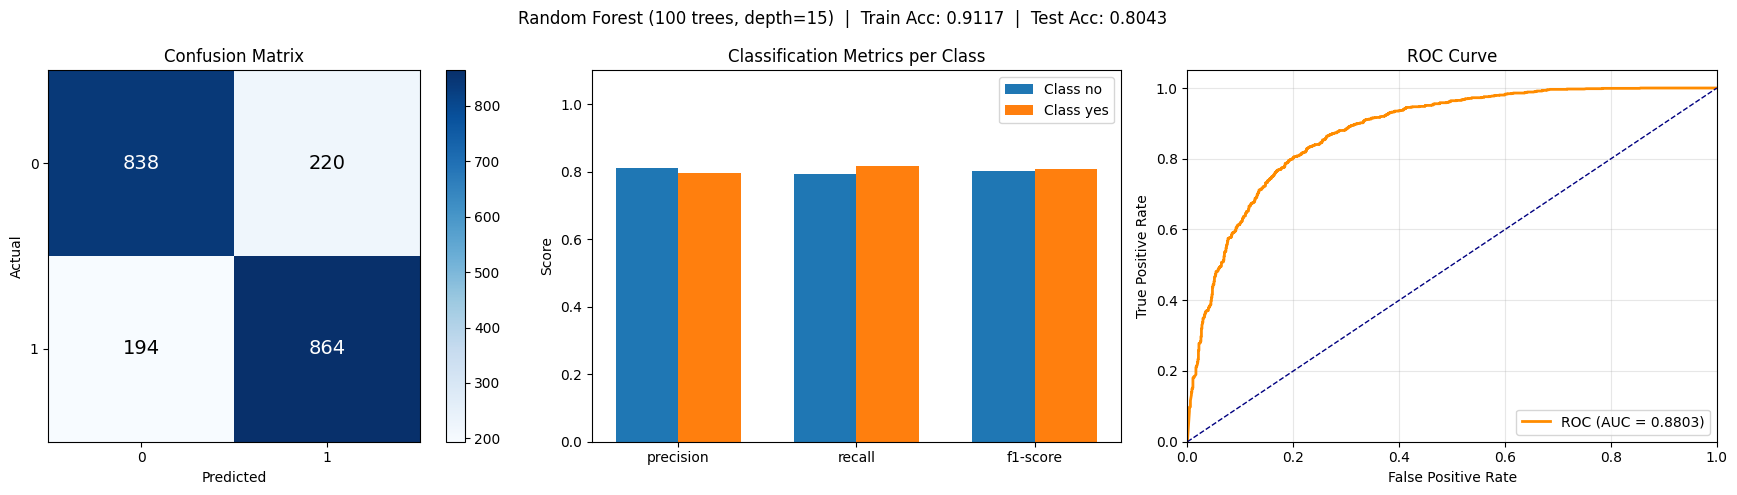


  Random Forest (100 trees, depth=15) — Detailed Metrics
  Accuracy                  0.8043
  Precision (PPV)           0.7970
  Sensitivity (Recall/TPR)  0.8166
  Specificity (TNR)         0.7921
  F1-score                  0.8067
  AUC                       0.8803
  TP                        864
  TN                        838
  FP                        220
  FN                        194
              precision    recall  f1-score   support

          no       0.81      0.79      0.80      1058
         yes       0.80      0.82      0.81      1058

    accuracy                           0.80      2116
   macro avg       0.80      0.80      0.80      2116
weighted avg       0.80      0.80      0.80      2116



In [17]:
rf_prob = rf.predict_proba(X_test)
plot_summary("Random Forest (100 trees, depth=15)", rf_train_acc, rf_test_acc, Y_test, rf_pred, Y_prob=rf_prob)

## Support Vector Machine

In [18]:
class SVM:
    """Support Vector Machine (linear) using hinge loss + SGD."""
    def __init__(self, lr=0.001, lambda_param=0.01, num_epochs=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.num_epochs = num_epochs
        self.weights = None
        self.bias = None
        self.history = None

    def _decision_function(self, X):
        return X @ self.weights + self.bias

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        y_svm = np.where(y <= 0, -1, 1)

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}

        pbar = tqdm(range(self.num_epochs), desc="SVM Training")
        for epoch in pbar:
            for i in range(n_samples):
                condition = y_svm[i] * (X[i] @ self.weights + self.bias) >= 1
                if condition:
                    self.weights -= self.lr * (2 * self.lambda_param * self.weights)
                else:
                    self.weights -= self.lr * (2 * self.lambda_param * self.weights - y_svm[i] * X[i])
                    self.bias -= self.lr * (-y_svm[i])

            margins = y_svm * self._decision_function(X)
            hinge = np.maximum(0, 1 - margins)
            loss = self.lambda_param * np.dot(self.weights, self.weights) + np.mean(hinge)
            preds = self.predict(X)
            acc = np.mean(preds == y)
            self.history["loss"].append(loss)
            self.history["acc"].append(acc)

            if X_val is not None and y_val is not None:
                y_val_svm = np.where(y_val <= 0, -1, 1)
                margins_val = y_val_svm * self._decision_function(X_val)
                hinge_val = np.maximum(0, 1 - margins_val)
                val_loss = self.lambda_param * np.dot(self.weights, self.weights) + np.mean(hinge_val)
                val_preds = self.predict(X_val)
                val_acc = np.mean(val_preds == y_val)
                self.history["val_loss"].append(val_loss)
                self.history["val_acc"].append(val_acc)

            pbar.set_postfix(loss=f"{loss:.4f}", acc=f"{acc:.4f}")

    def predict(self, X):
        return np.where(self._decision_function(X) >= 0, 1, 0)

    def decision_scores(self, X):
        """Raw decision function values (used for ROC)."""
        return self._decision_function(X)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [19]:
svm = SVM(lr=0.001, lambda_param=0.01, num_epochs=500)
svm.fit(X_train, Y_train, X_test, Y_test)

svm_train_acc = svm.accuracy(X_train, Y_train)
svm_test_acc = svm.accuracy(X_test, Y_test)
svm_pred = svm.predict(X_test)
svm_scores = svm.decision_scores(X_test)

print(f"SVM - Train Accuracy: {svm_train_acc:.4f}, Test Accuracy: {svm_test_acc:.4f}")

SVM Training: 100%|██████████| 500/500 [00:12<00:00, 38.79it/s, acc=0.7603, loss=0.4952]

SVM - Train Accuracy: 0.7603, Test Accuracy: 0.7817


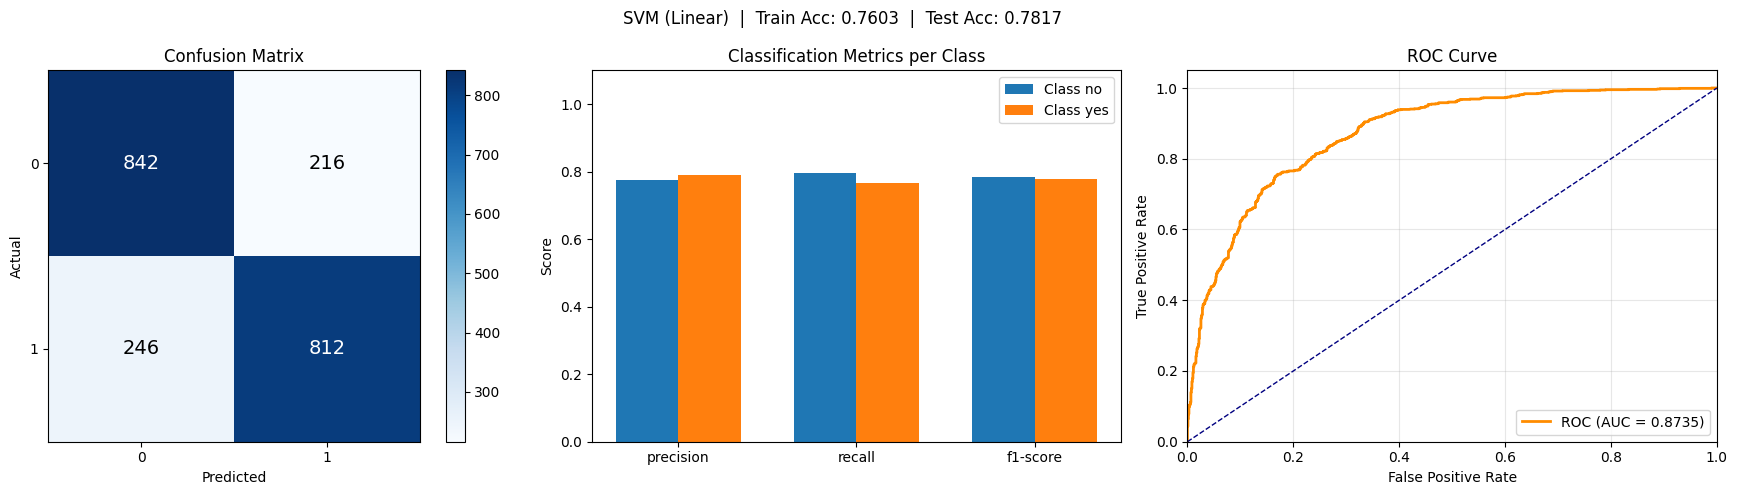


  SVM (Linear) — Detailed Metrics
  Accuracy                  0.7817
  Precision (PPV)           0.7899
  Sensitivity (Recall/TPR)  0.7675
  Specificity (TNR)         0.7958
  F1-score                  0.7785
  AUC                       0.8735
  TP                        812
  TN                        842
  FP                        216
  FN                        246
              precision    recall  f1-score   support

          no       0.77      0.80      0.78      1058
         yes       0.79      0.77      0.78      1058

    accuracy                           0.78      2116
   macro avg       0.78      0.78      0.78      2116
weighted avg       0.78      0.78      0.78      2116



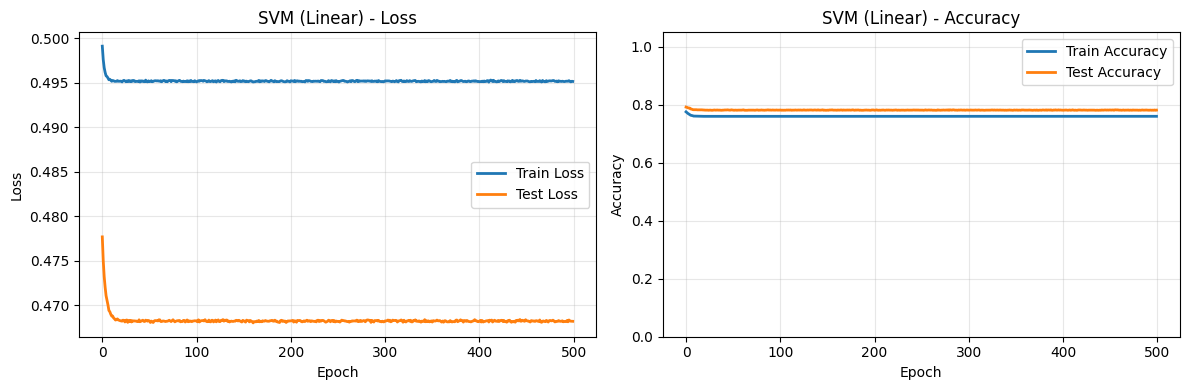

In [20]:
plot_summary("SVM (Linear)", svm_train_acc, svm_test_acc, Y_test, svm_pred, Y_prob=svm_scores)
plot_loss_history("SVM (Linear)", svm.history)

## Dimensionality Reduction (PCA) for Random Forest / SVM

In [21]:
class PCA:
    """Principal Component Analysis from scratch."""
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        return self

    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Original features: 14 -> PCA components: 7
Explained variance ratio: [0.34494609 0.22127307 0.11577842 0.09300138 0.07472113 0.06383288
 0.02678792]
Total explained variance: 0.9403


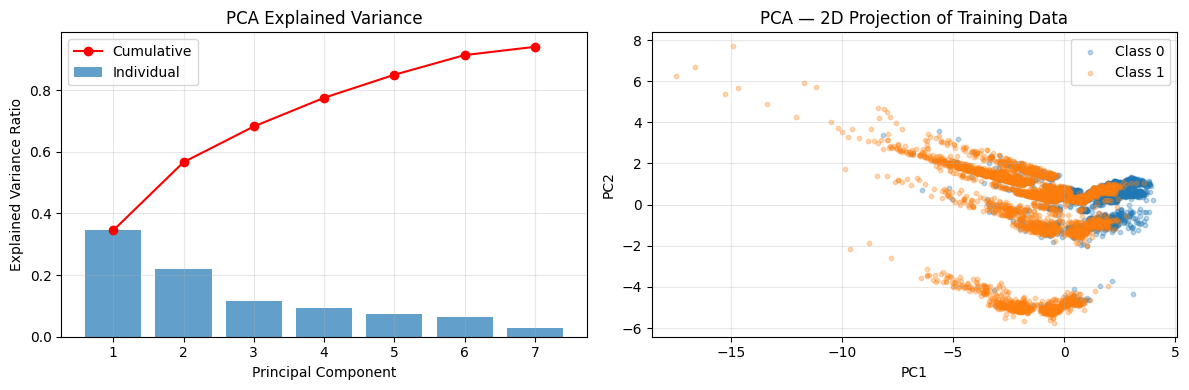

In [22]:
n_components = 7
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train).astype(np.float32)
X_test_pca = pca.transform(X_test).astype(np.float32)

print(f"Original features: {X_train.shape[1]} -> PCA components: {n_components}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_, alpha=0.7, label='Individual')
axes[0].plot(range(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_train_pca[Y_train == 0, 0], X_train_pca[Y_train == 0, 1], alpha=0.3, label='Class 0', s=10)
axes[1].scatter(X_train_pca[Y_train == 1, 0], X_train_pca[Y_train == 1, 1], alpha=0.3, label='Class 1', s=10)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA — 2D Projection of Training Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Building trees: 100%|██████████| 100/100 [20:37<00:00, 12.37s/it]


RF+PCA - Train Accuracy: 0.9273, Test Accuracy: 0.7954


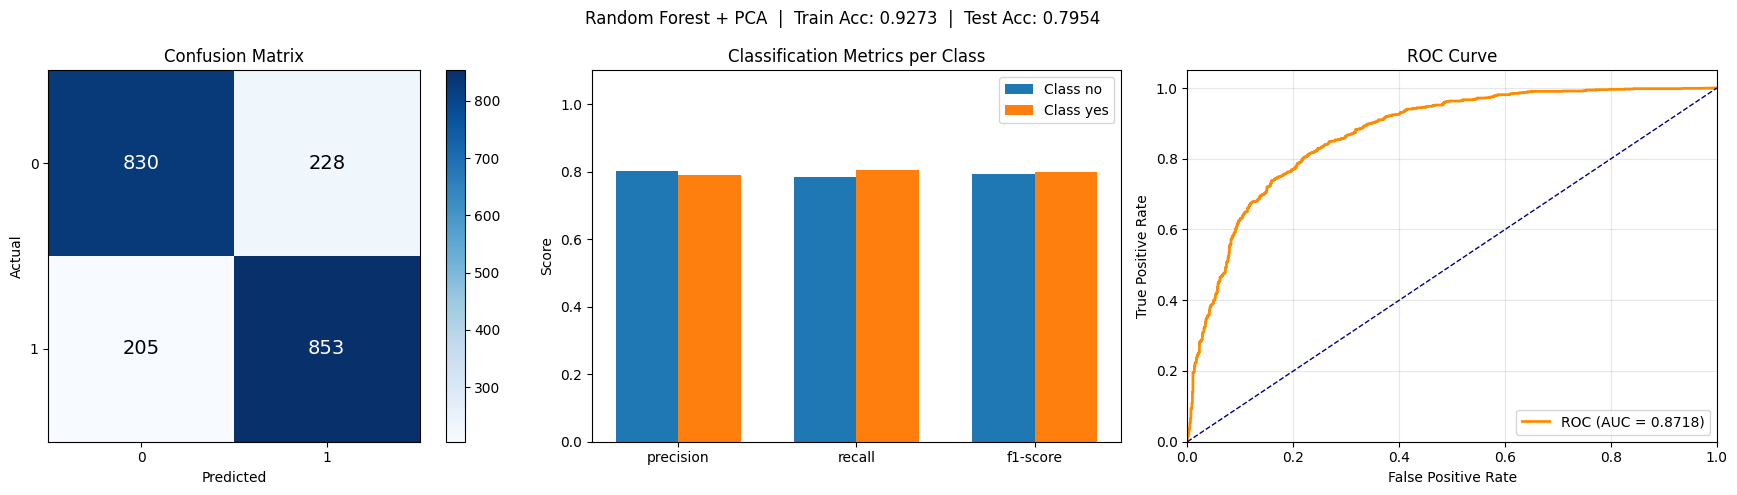


  Random Forest + PCA — Detailed Metrics
  Accuracy                  0.7954
  Precision (PPV)           0.7891
  Sensitivity (Recall/TPR)  0.8062
  Specificity (TNR)         0.7845
  F1-score                  0.7976
  AUC                       0.8718
  TP                        853
  TN                        830
  FP                        228
  FN                        205
              precision    recall  f1-score   support

          no       0.80      0.78      0.79      1058
         yes       0.79      0.81      0.80      1058

    accuracy                           0.80      2116
   macro avg       0.80      0.80      0.80      2116
weighted avg       0.80      0.80      0.80      2116



In [23]:
rf_pca = RandomForest(n_trees=100, max_depth=15)
rf_pca.fit(X_train_pca, Y_train, X_test_pca, Y_test)

rf_pca_train_acc = rf_pca.accuracy(X_train_pca, Y_train)
rf_pca_test_acc = rf_pca.accuracy(X_test_pca, Y_test)
rf_pca_pred = rf_pca.predict(X_test_pca)
rf_pca_prob = rf_pca.predict_proba(X_test_pca)

print(f"RF+PCA - Train Accuracy: {rf_pca_train_acc:.4f}, Test Accuracy: {rf_pca_test_acc:.4f}")
plot_summary("Random Forest + PCA", rf_pca_train_acc, rf_pca_test_acc, Y_test, rf_pca_pred, Y_prob=rf_pca_prob)

SVM Training: 100%|██████████| 500/500 [00:13<00:00, 37.23it/s, acc=0.7738, loss=0.5021]


SVM+PCA - Train Accuracy: 0.7738, Test Accuracy: 0.7921


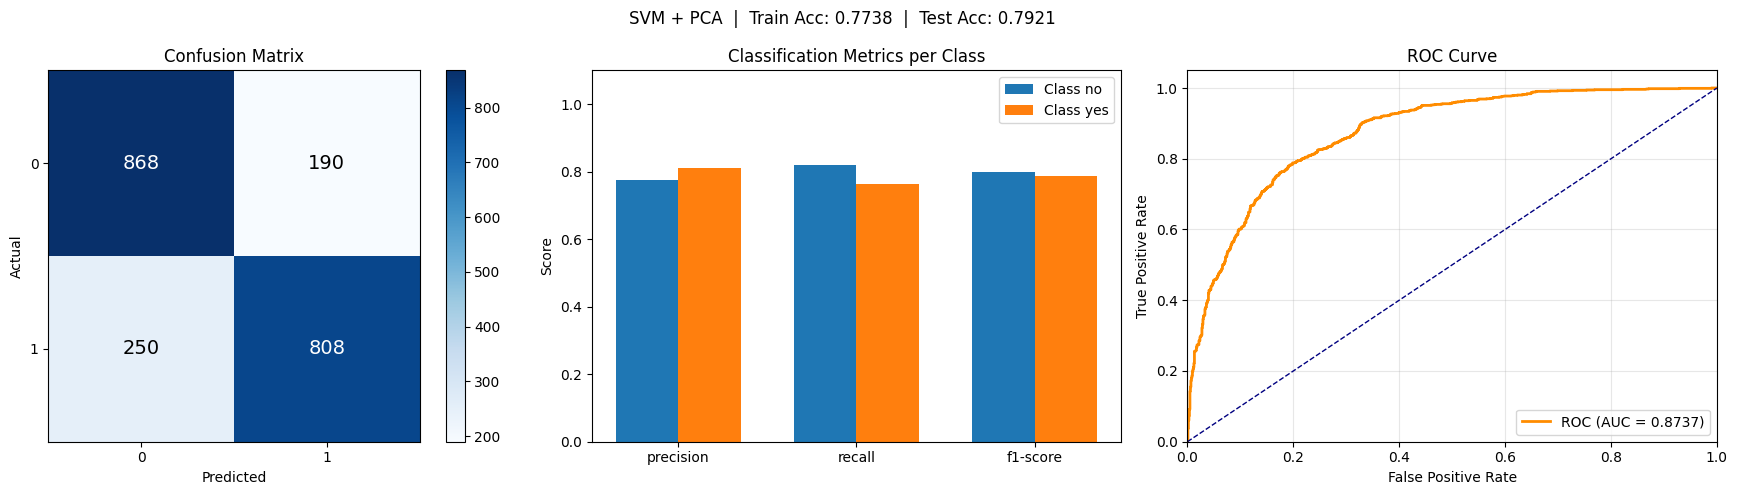


  SVM + PCA — Detailed Metrics
  Accuracy                  0.7921
  Precision (PPV)           0.8096
  Sensitivity (Recall/TPR)  0.7637
  Specificity (TNR)         0.8204
  F1-score                  0.7860
  AUC                       0.8737
  TP                        808
  TN                        868
  FP                        190
  FN                        250
              precision    recall  f1-score   support

          no       0.78      0.82      0.80      1058
         yes       0.81      0.76      0.79      1058

    accuracy                           0.79      2116
   macro avg       0.79      0.79      0.79      2116
weighted avg       0.79      0.79      0.79      2116



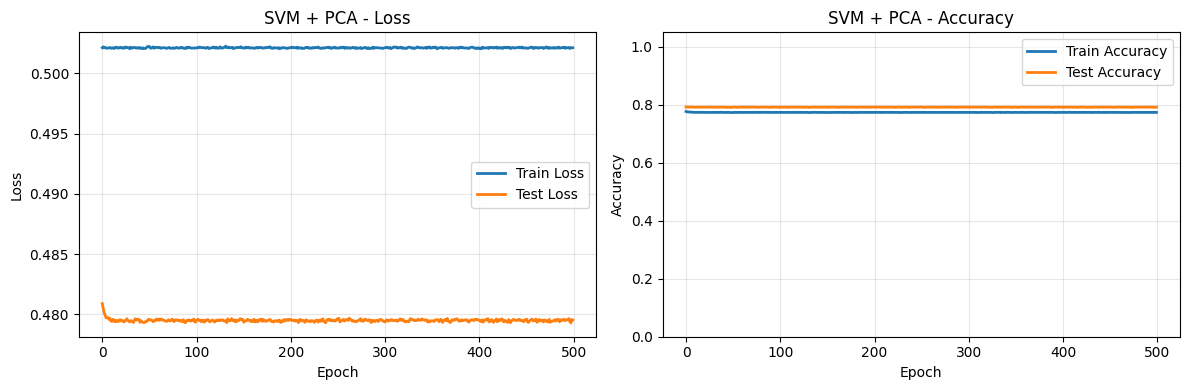

In [24]:
svm_pca = SVM(lr=0.001, lambda_param=0.01, num_epochs=500)
svm_pca.fit(X_train_pca, Y_train, X_test_pca, Y_test)

svm_pca_train_acc = svm_pca.accuracy(X_train_pca, Y_train)
svm_pca_test_acc = svm_pca.accuracy(X_test_pca, Y_test)
svm_pca_pred = svm_pca.predict(X_test_pca)
svm_pca_scores = svm_pca.decision_scores(X_test_pca)

print(f"SVM+PCA - Train Accuracy: {svm_pca_train_acc:.4f}, Test Accuracy: {svm_pca_test_acc:.4f}")
plot_summary("SVM + PCA", svm_pca_train_acc, svm_pca_test_acc, Y_test, svm_pca_pred, Y_prob=svm_pca_scores)
plot_loss_history("SVM + PCA", svm_pca.history)

## Unsupervised k-mean and agglomerative clustering

In [25]:
class KMeans:
    """K-Means clustering from scratch."""
    def __init__(self, n_clusters=2, max_iters=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[indices].copy()

        for it in tqdm(range(self.max_iters), desc="K-Means"):
            distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids]).T
            labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        self.labels_ = labels
        self.inertia_ = sum(
            np.sum((X[labels == k] - self.centroids[k]) ** 2)
            for k in range(self.n_clusters)
        )
        return self

    def predict(self, X):
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids]).T
        return np.argmin(distances, axis=1)

class AgglomerativeClustering:
    """Agglomerative (bottom-up) hierarchical clustering from scratch."""
    def __init__(self, n_clusters=2, linkage='ward'):
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels_ = None

    def _distance(self, c1, c2, X):
        if self.linkage == 'single':
            return min(np.linalg.norm(X[i] - X[j]) for i in c1 for j in c2)
        elif self.linkage == 'complete':
            return max(np.linalg.norm(X[i] - X[j]) for i in c1 for j in c2)
        elif self.linkage == 'average':
            dists = [np.linalg.norm(X[i] - X[j]) for i in c1 for j in c2]
            return np.mean(dists)
        elif self.linkage == 'ward':
            merged = np.vstack([X[list(c1)], X[list(c2)]])
            centroid = merged.mean(axis=0)
            return (np.sum((merged - centroid) ** 2)
                    - np.sum((X[list(c1)] - X[list(c1)].mean(axis=0)) ** 2)
                    - np.sum((X[list(c2)] - X[list(c2)].mean(axis=0)) ** 2))

    def fit(self, X):
        n_samples = X.shape[0]
        clusters = {i: {i} for i in range(n_samples)}

        total_merges = n_samples - self.n_clusters
        pbar = tqdm(total=total_merges, desc="Agglomerative Clustering")
        while len(clusters) > self.n_clusters:
            keys = list(clusters.keys())
            min_dist = float('inf')
            merge_pair = (None, None)
            for i_idx in range(len(keys)):
                for j_idx in range(i_idx + 1, len(keys)):
                    d = self._distance(clusters[keys[i_idx]], clusters[keys[j_idx]], X)
                    if d < min_dist:
                        min_dist = d
                        merge_pair = (keys[i_idx], keys[j_idx])

            k1, k2 = merge_pair
            clusters[k1] = clusters[k1] | clusters[k2]
            del clusters[k2]
            pbar.update(1)
            pbar.set_postfix(remaining=len(clusters))
        pbar.close()

        self.labels_ = np.zeros(n_samples, dtype=int)
        for label, (_, members) in enumerate(clusters.items()):
            for idx in members:
                self.labels_[idx] = label
        return self

K-Means:   2%|▏         | 7/300 [00:00<00:00, 1831.00it/s]


K-Means cluster → class mapping (majority vote): {0: 0, 1: 1}
Running Agglomerative Clustering on 300 test samples...


Agglomerative Clustering: 100%|██████████| 298/298 [01:47<00:00,  2.77it/s, remaining=2]  


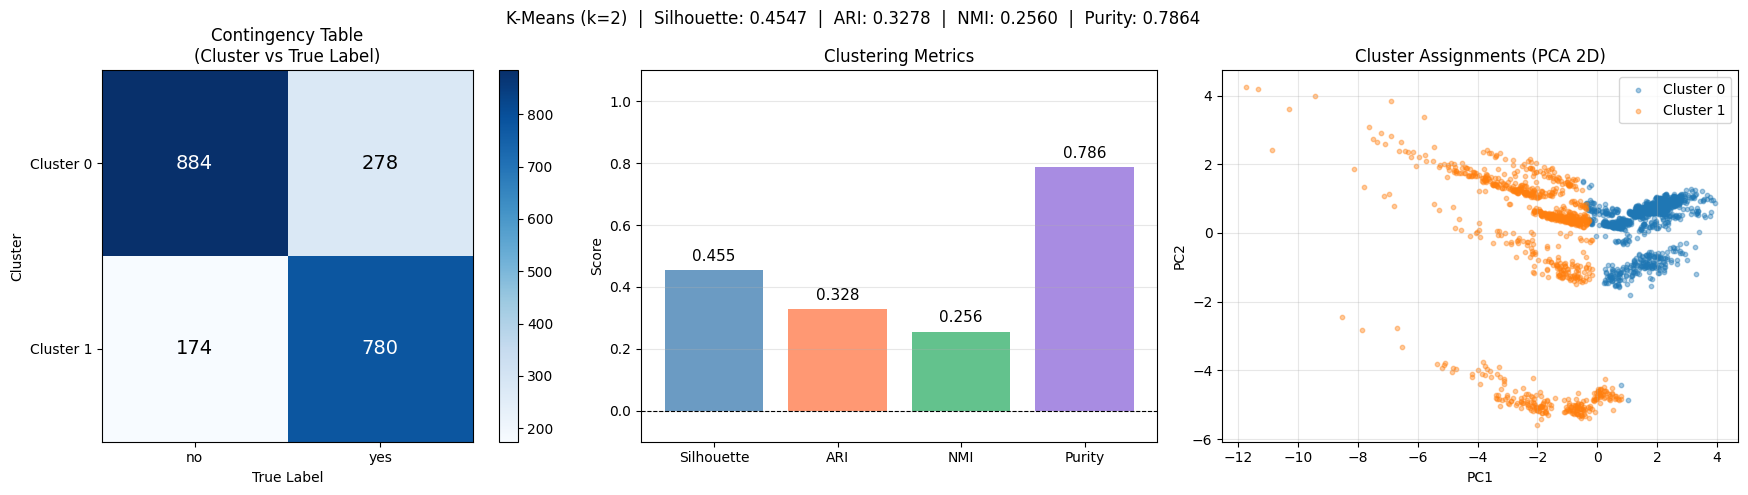


  K-Means (k=2) — Detailed Metrics
  Silhouette Score               0.4547
  Adjusted Rand Index (ARI)      0.3278
  Normalized Mutual Info (NMI)   0.2560
  Cluster Purity                 0.7864

  Contingency Table (Cluster → True Label):
  Cluster  |  Class no  |  Class yes  |
  -------------------------------------
       0     |     884    |     278    |
       1     |     174    |     780    |


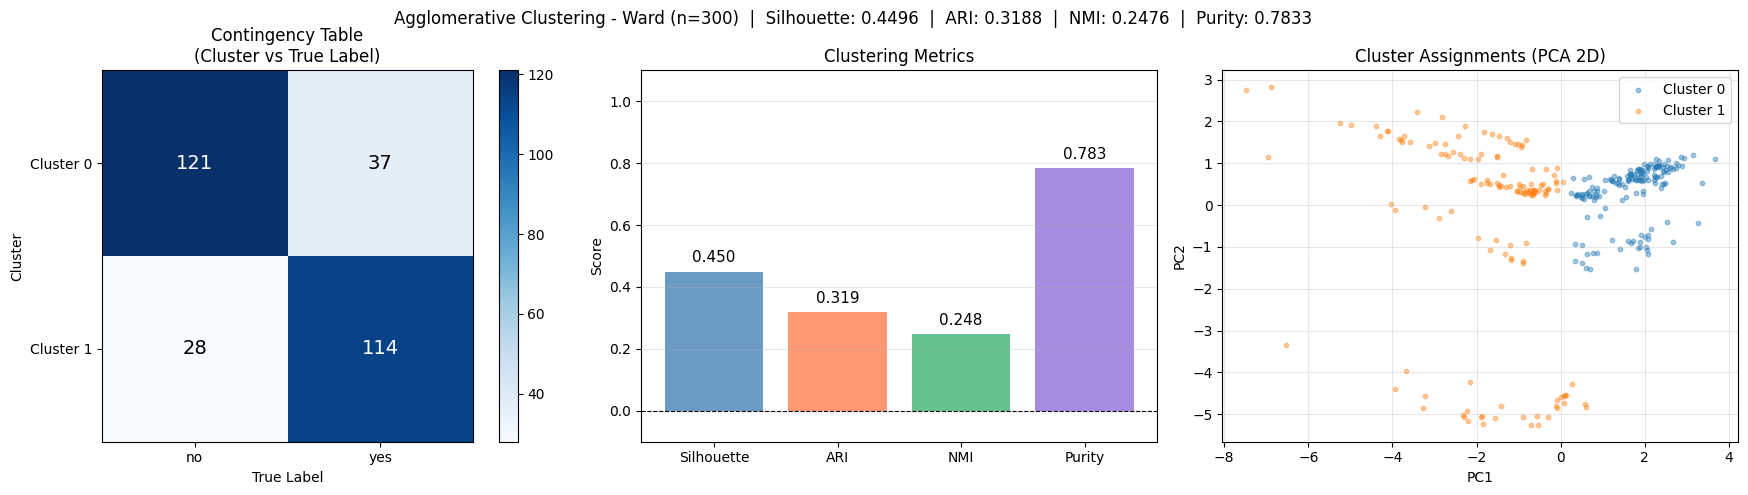


  Agglomerative Clustering - Ward (n=300) — Detailed Metrics
  Silhouette Score               0.4496
  Adjusted Rand Index (ARI)      0.3188
  Normalized Mutual Info (NMI)   0.2476
  Cluster Purity                 0.7833

  Contingency Table (Cluster → True Label):
  Cluster  |  Class no  |  Class yes  |
  -------------------------------------
       0     |     121    |      37    |
       1     |      28    |     114    |


In [26]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

pca_2d = PCA(n_components=2)
pca_2d.fit(X_train)
X_vis_train = pca_2d.transform(X_train).astype(np.float32)
X_vis_test  = pca_2d.transform(X_test).astype(np.float32)

kmeans = KMeans(n_clusters=2, max_iters=300)
kmeans.fit(X_vis_train)

cluster_to_class = {
    k: int(np.bincount(Y_train[kmeans.labels_ == k]).argmax())
    for k in range(kmeans.n_clusters)
}
print(f"K-Means cluster → class mapping (majority vote): {cluster_to_class}")

raw_km_test = kmeans.predict(X_vis_test)
km_labels = np.array([cluster_to_class[c] for c in raw_km_test])

subsample_size = min(300, len(X_vis_test))
np.random.seed(42)
sub_idx = np.random.choice(len(X_vis_test), subsample_size, replace=False)
X_vis_sub = X_vis_test[sub_idx]
Y_test_sub = Y_test[sub_idx]

print(f"Running Agglomerative Clustering on {subsample_size} test samples...")
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg.fit(X_vis_sub)
agg_labels = agg.labels_

plot_cluster_summary("K-Means (k=2)", X_vis_test, km_labels, Y_test)
plot_cluster_summary(f"Agglomerative Clustering - Ward (n={subsample_size})", X_vis_sub, agg_labels, Y_test_sub)

## Perceptron & Single-layer perceptron (SLP)


In [27]:
class SLP:
    """Single-Layer Perceptron (SLP) with sigmoid activation"""
    def __init__(self, lr=0.01, num_epochs=1000):
        self.lr = lr
        self.num_epochs = num_epochs
        self.weights = None
        self.bias = None
        self.history = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def _binary_ce_loss(self, y, y_pred):
        eps = 1e-7
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}

        for epoch in range(self.num_epochs):
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)
            
            dw = X.T @ (y_pred - y) / n_samples
            db = np.mean(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            loss = self._binary_ce_loss(y, y_pred)
            acc = np.mean((y_pred >= 0.5).astype(int) == y)
            self.history["loss"].append(loss)
            self.history["acc"].append(acc)
            
            if X_val is not None and y_val is not None:
                z_val = X_val @ self.weights + self.bias
                y_val_pred = self.sigmoid(z_val)
                val_loss = self._binary_ce_loss(y_val, y_val_pred)
                val_acc = np.mean((y_val_pred >= 0.5).astype(int) == y_val)
                self.history["val_loss"].append(val_loss)
                self.history["val_acc"].append(val_acc)

    def predict_proba(self, X):
        z = X @ self.weights + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

In [28]:
slp = SLP(lr=0.01, num_epochs=1000)
slp.fit(X_train, Y_train, X_test, Y_test)

slp_train_acc = slp.accuracy(X_train, Y_train)
slp_test_acc = slp.accuracy(X_test, Y_test)
slp_pred = slp.predict(X_test)

print(f"SLP - Train Accuracy: {slp_train_acc:.4f}, Test Accuracy: {slp_test_acc:.4f}")

SLP - Train Accuracy: 0.7785, Test Accuracy: 0.7921


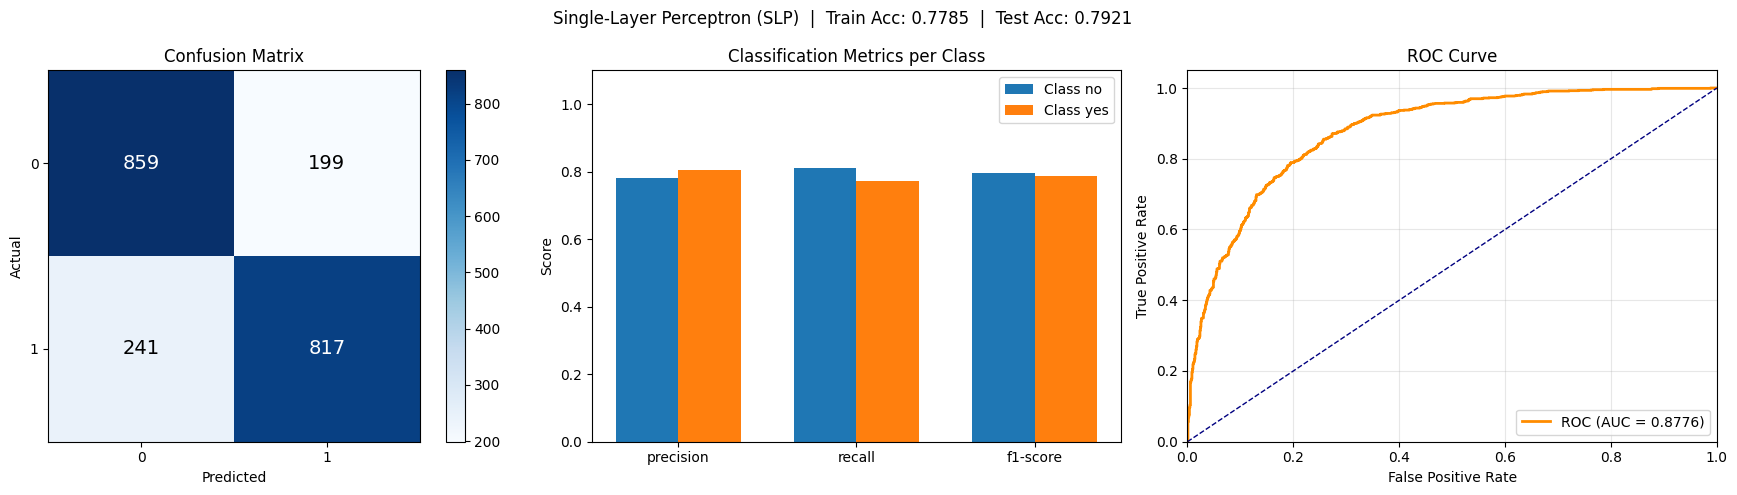


  Single-Layer Perceptron (SLP) — Detailed Metrics
  Accuracy                  0.7921
  Precision (PPV)           0.8041
  Sensitivity (Recall/TPR)  0.7722
  Specificity (TNR)         0.8119
  F1-score                  0.7878
  AUC                       0.8776
  TP                        817
  TN                        859
  FP                        199
  FN                        241
              precision    recall  f1-score   support

          no       0.78      0.81      0.80      1058
         yes       0.80      0.77      0.79      1058

    accuracy                           0.79      2116
   macro avg       0.79      0.79      0.79      2116
weighted avg       0.79      0.79      0.79      2116



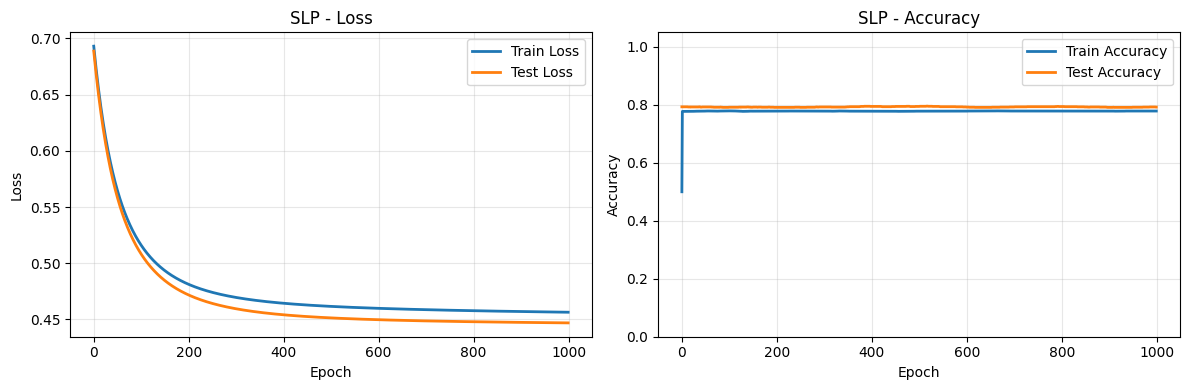

In [29]:
slp_prob = slp.predict_proba(X_test)
plot_summary("Single-Layer Perceptron (SLP)", slp_train_acc, slp_test_acc, Y_test, slp_pred, Y_prob=slp_prob)
plot_loss_history("SLP", slp.history)

## Multi-layer perceptron (MLP)

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 1)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        return self.network(x)

mlp_torch = MLP(input_size=X_train.shape[1]).to(device)
optimizer = torch.optim.AdamW(mlp_torch.parameters(), lr=0.0005, weight_decay=1e-3)
criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss instead of BCELoss

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

history_torch = train(mlp_torch, train_loader, test_loader, optimizer, criterion, device, num_epochs=100)

mlp_torch.eval()
with torch.no_grad():
    y_train_pred_torch = mlp_torch(x_train_tensor.to(device)).cpu().numpy()
    y_test_pred_torch = mlp_torch(x_test_tensor.to(device)).cpu().numpy()
    
mlp_torch_train_acc = np.mean((y_train_pred_torch >= 0.5).astype(int).squeeze() == Y_train)
mlp_torch_test_acc = np.mean((y_test_pred_torch >= 0.5).astype(int).squeeze() == Y_test)
mlp_torch_pred = (y_test_pred_torch >= 0.5).astype(int).squeeze()

print(f"PyTorch MLP - Train Accuracy: {mlp_torch_train_acc:.4f}, Test Accuracy: {mlp_torch_test_acc:.4f}")

Epoch 1/100 | Train Loss: 0.5590 | Train Acc: 0.7230 | Test Loss: 0.4450 | Test Acc: 0.7916


Epoch 2/100 | Train Loss: 0.4995 | Train Acc: 0.7616 | Test Loss: 0.4315 | Test Acc: 0.7968


Epoch 3/100 | Train Loss: 0.4837 | Train Acc: 0.7680 | Test Loss: 0.4329 | Test Acc: 0.7987


Epoch 4/100 | Train Loss: 0.4808 | Train Acc: 0.7740 | Test Loss: 0.4297 | Test Acc: 0.7982


Epoch 5/100 | Train Loss: 0.4753 | Train Acc: 0.7765 | Test Loss: 0.4323 | Test Acc: 0.8001


...

Epoch 96/100 | Train Loss: 0.4431 | Train Acc: 0.7889 | Test Loss: 0.4170 | Test Acc: 0.8086


Epoch 97/100 | Train Loss: 0.4454 | Train Acc: 0.7893 | Test Loss: 0.4159 | Test Acc: 0.8138


Epoch 98/100 | Train Loss: 0.4403 | Train Acc: 0.7862 | Test Loss: 0.4213 | Test Acc: 0.8039


Epoch 99/100 | Train Loss: 0.4445 | Train Acc: 0.7921 | Test Loss: 0.4142 | Test Acc: 0.8077


Epoch 100/100 | Train Loss: 0.4393 | Train Acc: 0.7899 | Test Loss: 0.4168 | Test Acc: 0.8086
PyTorch MLP - Train Accuracy: 0.7803, Test Accuracy: 0.7930


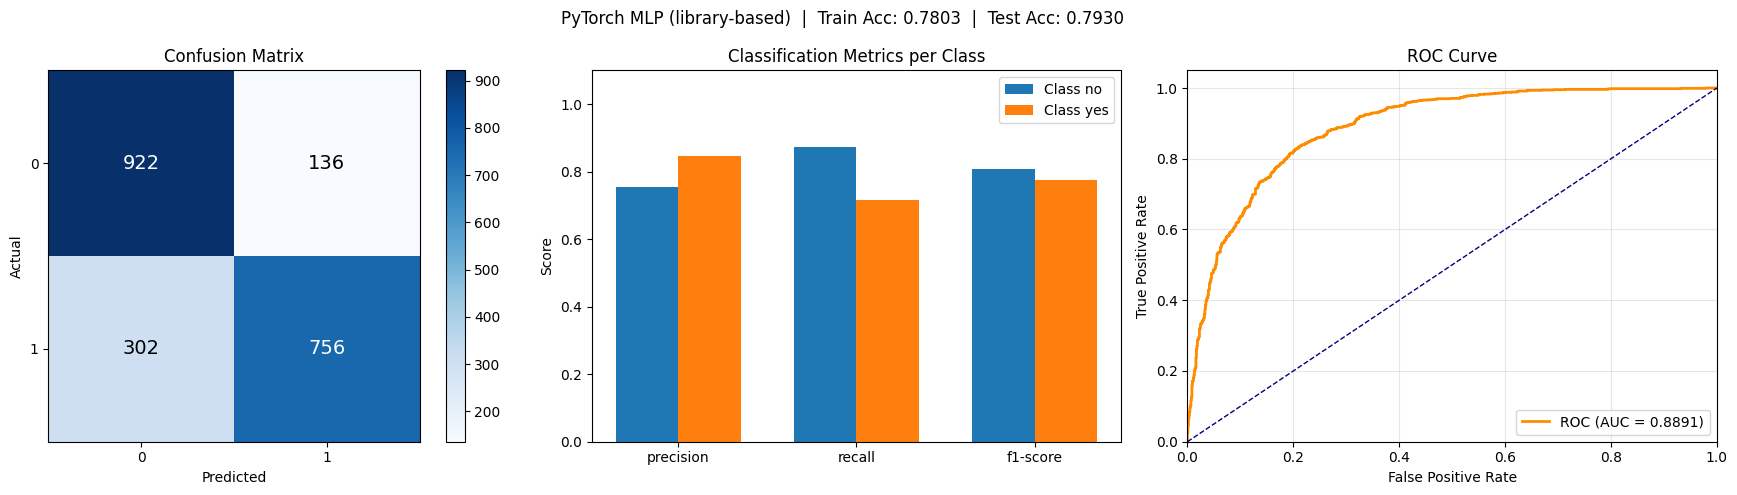


  PyTorch MLP (library-based) — Detailed Metrics
  Accuracy                  0.7930
  Precision (PPV)           0.8475
  Sensitivity (Recall/TPR)  0.7146
  Specificity (TNR)         0.8715
  F1-score                  0.7754
  AUC                       0.8891
  TP                        756
  TN                        922
  FP                        136
  FN                        302
              precision    recall  f1-score   support

          no       0.75      0.87      0.81      1058
         yes       0.85      0.71      0.78      1058

    accuracy                           0.79      2116
   macro avg       0.80      0.79      0.79      2116
weighted avg       0.80      0.79      0.79      2116



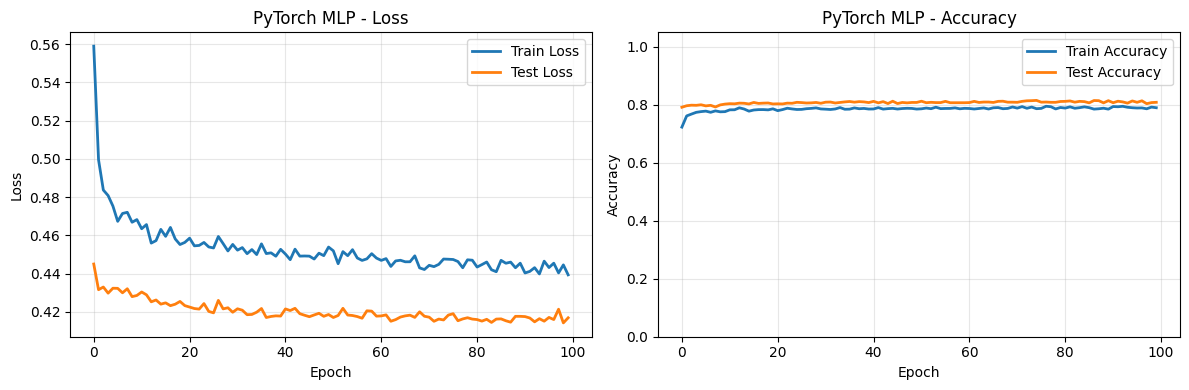

In [31]:
mlp_prob = 1 / (1 + np.exp(-y_test_pred_torch.squeeze()))
plot_summary("PyTorch MLP (library-based)", mlp_torch_train_acc, mlp_torch_test_acc, Y_test, mlp_torch_pred, Y_prob=mlp_prob)

history_torch_formatted = {
    "loss": history_torch["train_loss"],
    "acc": history_torch["train_acc"],
    "val_loss": history_torch["test_loss"],
    "val_acc": history_torch["test_acc"]
}
plot_loss_history("PyTorch MLP", history_torch_formatted)